# Notebook 2 — Exploratory Data Analysis
**Project:** E-commerce Customer Segmentation & Revenue Risk Scoring  
**Dataset:** UCI Online Retail II (2009–2011)  
**Author:** Pratiksha Dandriyal

---

## Objective
Understand the revenue shape of the business before building any segmentation model. EDA answers five key business questions:

1. How did revenue trend over the 2-year period?
2. Which countries drive the most revenue?
3. Which products are the top revenue contributors?
4. How concentrated is revenue across customers (Pareto)?
5. What share of customers are repeat buyers vs one-time buyers?

---
## 1. Imports & settings

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import numpy as np
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 130
plt.rcParams['font.family'] = 'DejaVu Sans'
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False

GREEN  = '#1D9E75'
PURPLE = '#7F77DD'
AMBER  = '#EF9F27'
CORAL  = '#D85A30'
GRAY   = '#888780'

FILE_PATH  = r'C:\Users\prati_t686nlu\OneDrive\Desktop\clean_retail.csv'
OUTPUT_DIR = r'C:\Users\prati_t686nlu\OneDrive\Desktop'

---
## 2. Load clean data

In [2]:
df = pd.read_csv(FILE_PATH, parse_dates=['InvoiceDate'])
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

print(f'Shape       : {df.shape}')
print(f'Date range  : {df["InvoiceDate"].min().date()} to {df["InvoiceDate"].max().date()}')
print(f'Customers   : {df["Customer ID"].nunique():,}')
print(f'Products    : {df["StockCode"].nunique():,}')
print(f'Total rev   : \u00a3{df["TotalRevenue"].sum():,.0f}')
df.head(3)

Shape       : (805549, 13)
Date range  : 2009-12-01 to 2011-12-09
Customers   : 5,878
Products    : 4,631
Total rev   : £17,743,429


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalRevenue,Year,Month,YearMonth,DayOfWeek
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085,United Kingdom,83.4,2009,12,2009-12,Tuesday
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12,Tuesday
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085,United Kingdom,81.0,2009,12,2009-12,Tuesday


---
## 3. Monthly revenue trend

**Business question:** Is the business growing, declining, or seasonal?

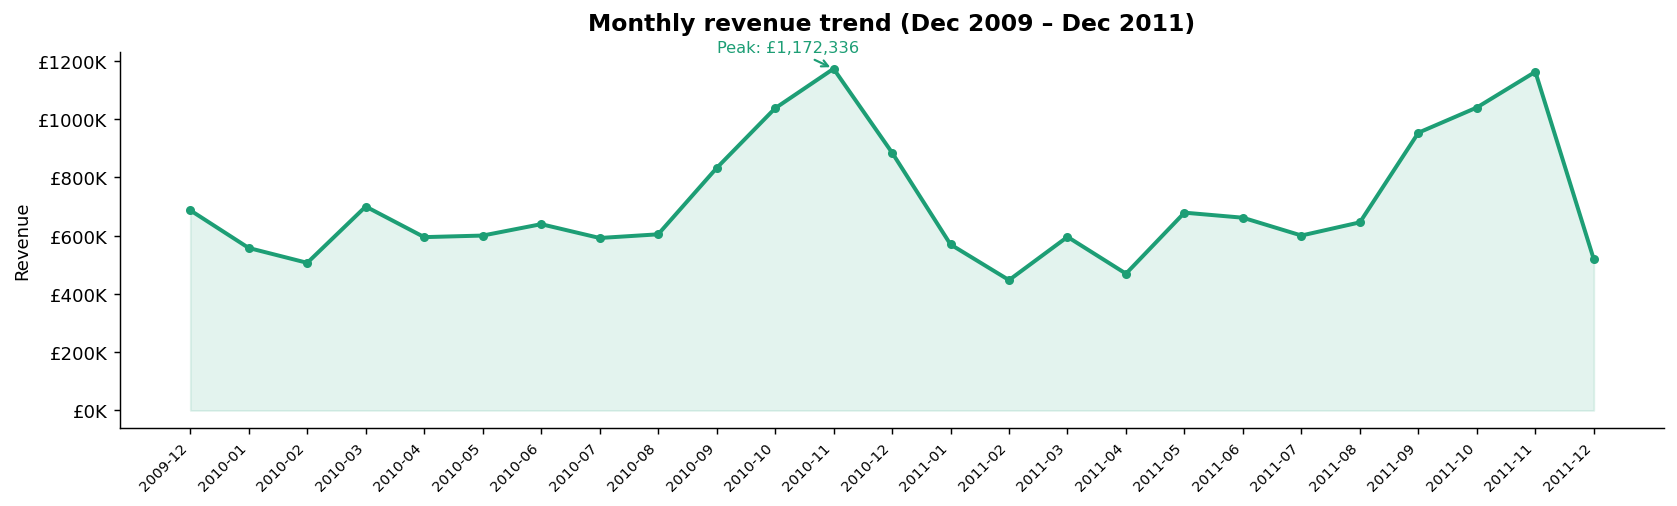


Peak month  : 2010-11
Peak revenue: £1,172,336


In [3]:
monthly_rev = df.groupby('YearMonth')['TotalRevenue'].sum().reset_index()
monthly_rev['YearMonth_str'] = monthly_rev['YearMonth'].astype(str)

fig, ax = plt.subplots(figsize=(13, 4))

ax.fill_between(range(len(monthly_rev)), monthly_rev['TotalRevenue'],
                alpha=0.12, color=GREEN)
ax.plot(range(len(monthly_rev)), monthly_rev['TotalRevenue'],
        color=GREEN, linewidth=2.2, marker='o', markersize=4)

# Annotate peak month
peak_idx = monthly_rev['TotalRevenue'].idxmax()
ax.annotate(
    f"Peak: \u00a3{monthly_rev.loc[peak_idx,'TotalRevenue']:,.0f}",
    xy=(peak_idx, monthly_rev.loc[peak_idx,'TotalRevenue']),
    xytext=(peak_idx - 2, monthly_rev.loc[peak_idx,'TotalRevenue'] * 1.05),
    fontsize=9, color=GREEN,
    arrowprops=dict(arrowstyle='->', color=GREEN, lw=1.2)
)

ax.set_xticks(range(len(monthly_rev)))
ax.set_xticklabels(monthly_rev['YearMonth_str'], rotation=45, ha='right', fontsize=8)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'\u00a3{x/1e3:.0f}K'))
ax.set_title('Monthly revenue trend (Dec 2009 – Dec 2011)', fontsize=13, fontweight='bold', pad=12)
ax.set_ylabel('Revenue')

plt.tight_layout()
plt.savefig(OUTPUT_DIR + r'\02_monthly_revenue.png', bbox_inches='tight')
plt.show()

print(f"\nPeak month  : {monthly_rev.loc[peak_idx,'YearMonth_str']}")
print(f"Peak revenue: \u00a3{monthly_rev.loc[peak_idx,'TotalRevenue']:,.0f}")

---
## 4. Revenue by country

**Business question:** How geographically concentrated is the customer base?

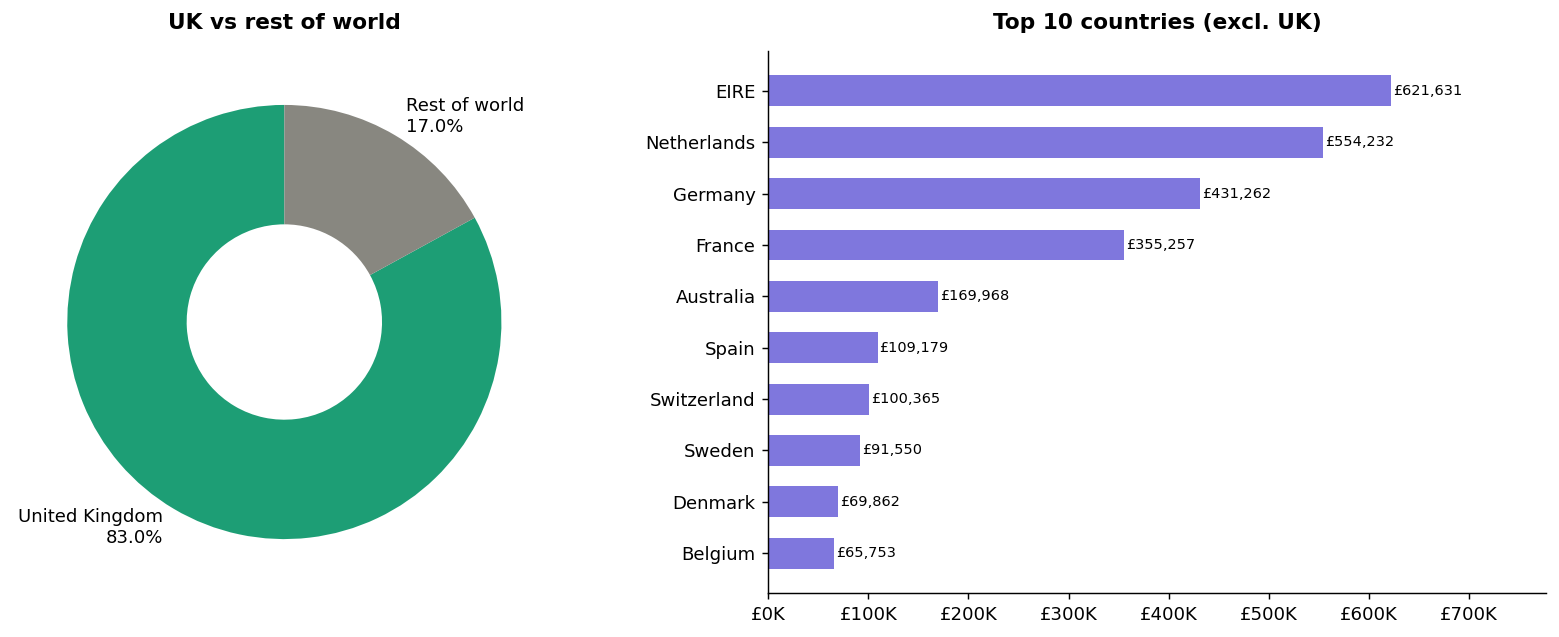

UK revenue share: 83.0%
Number of countries: 41


In [4]:
by_country = (df.groupby('Country')['TotalRevenue']
                .sum()
                .sort_values(ascending=False)
                .reset_index())

uk_share = by_country.loc[by_country['Country'] == 'United Kingdom', 'TotalRevenue'].values[0]
uk_pct   = uk_share / by_country['TotalRevenue'].sum() * 100

# Plot top 10 excluding UK so non-UK countries are visible
top10_ex_uk = by_country[by_country['Country'] != 'United Kingdom'].head(10)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Left: UK vs rest donut
ax1 = axes[0]
rest = by_country['TotalRevenue'].sum() - uk_share
ax1.pie([uk_share, rest],
        labels=[f'United Kingdom\n{uk_pct:.1f}%', f'Rest of world\n{100-uk_pct:.1f}%'],
        colors=[GREEN, GRAY],
        startangle=90, wedgeprops={'width': 0.55},
        textprops={'fontsize': 10})
ax1.set_title('UK vs rest of world', fontsize=12, fontweight='bold', pad=12)

# Right: Top 10 non-UK countries
ax2 = axes[1]
bars = ax2.barh(top10_ex_uk['Country'][::-1],
                top10_ex_uk['TotalRevenue'][::-1],
                color=PURPLE, height=0.6)
ax2.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'\u00a3{x/1e3:.0f}K'))
ax2.set_title('Top 10 countries (excl. UK)', fontsize=12, fontweight='bold', pad=12)
for bar, val in zip(bars, top10_ex_uk['TotalRevenue'][::-1]):
    ax2.text(bar.get_width() + 2000, bar.get_y() + bar.get_height()/2,
             f'\u00a3{val:,.0f}', va='center', fontsize=8)
ax2.set_xlim(0, top10_ex_uk['TotalRevenue'].max() * 1.25)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + r'\02_revenue_by_country.png', bbox_inches='tight')
plt.show()

print(f"UK revenue share: {uk_pct:.1f}%")
print(f"Number of countries: {df['Country'].nunique()}")

---
## 5. Top 20 products by revenue

**Business question:** Which SKUs are hero products driving disproportionate revenue?

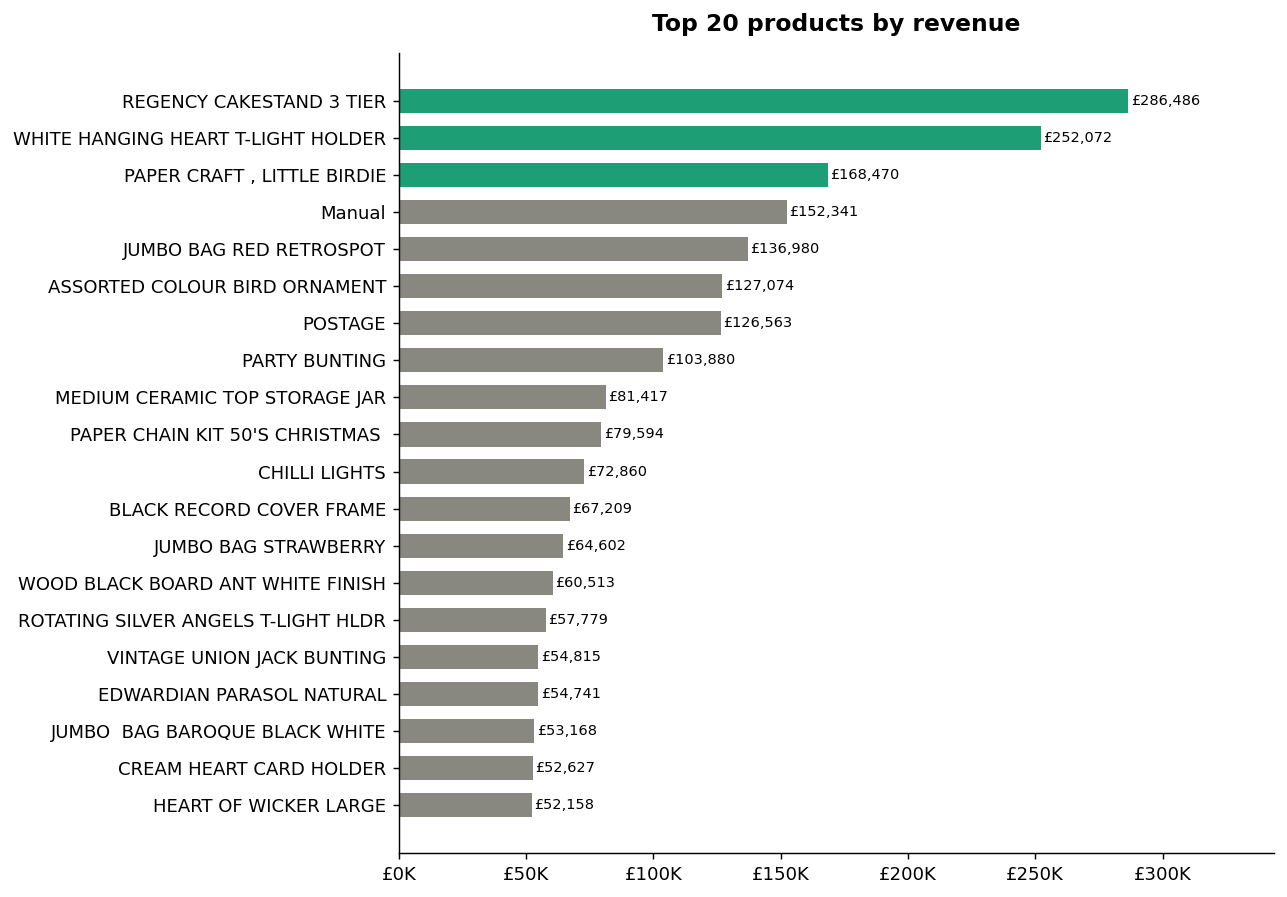

In [5]:
top_products = (df.groupby('Description')['TotalRevenue']
                  .sum()
                  .sort_values(ascending=False)
                  .head(20)
                  .reset_index())

fig, ax = plt.subplots(figsize=(10, 7))
colors  = [GREEN if i < 3 else GRAY for i in range(len(top_products))]
bars    = ax.barh(top_products['Description'][::-1],
                  top_products['TotalRevenue'][::-1],
                  color=colors[::-1], height=0.65)

ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'\u00a3{x/1e3:.0f}K'))
ax.set_title('Top 20 products by revenue', fontsize=13, fontweight='bold', pad=12)
for bar, val in zip(bars, top_products['TotalRevenue'][::-1]):
    ax.text(bar.get_width() + 1000, bar.get_y() + bar.get_height()/2,
            f'\u00a3{val:,.0f}', va='center', fontsize=8)
ax.set_xlim(0, top_products['TotalRevenue'].max() * 1.2)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + r'\02_top_products.png', bbox_inches='tight')
plt.show()

---
## 6. Revenue concentration — Pareto analysis

**Business question:** Do a small number of customers drive most of the revenue?

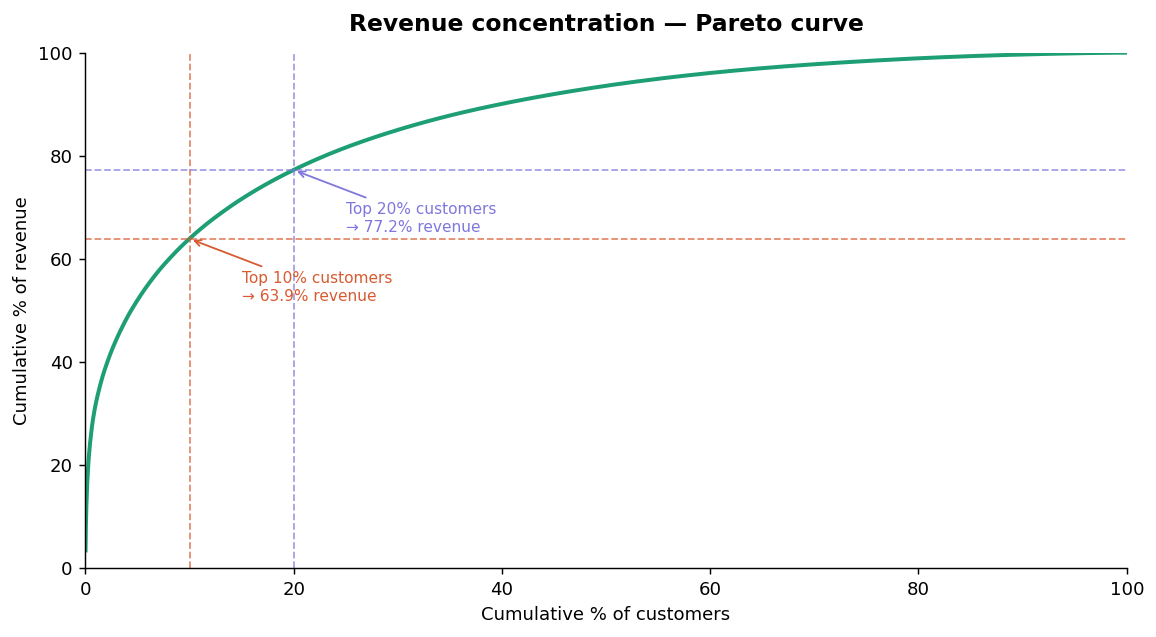

Top 10% customers drive 63.9% of revenue
Top 20% customers drive 77.2% of revenue


In [6]:
cust_rev    = (df.groupby('Customer ID')['TotalRevenue']
                 .sum()
                 .sort_values(ascending=False)
                 .reset_index())
total_rev   = cust_rev['TotalRevenue'].sum()
cust_rev['cumulative_pct'] = cust_rev['TotalRevenue'].cumsum() / total_rev * 100
cust_rev['customer_pct']   = (cust_rev.index + 1) / len(cust_rev) * 100

# Key stats
top10_rev = cust_rev[cust_rev['customer_pct'] <= 10]['TotalRevenue'].sum() / total_rev * 100
top20_rev = cust_rev[cust_rev['customer_pct'] <= 20]['TotalRevenue'].sum() / total_rev * 100

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(cust_rev['customer_pct'], cust_rev['cumulative_pct'],
        color=GREEN, linewidth=2.2)

# Reference lines
for pct, rev_pct, color in [(10, top10_rev, CORAL), (20, top20_rev, PURPLE)]:
    ax.axvline(pct,  linestyle='--', linewidth=1, color=color, alpha=0.7)
    ax.axhline(rev_pct, linestyle='--', linewidth=1, color=color, alpha=0.7)
    ax.annotate(f'Top {pct}% customers\n→ {rev_pct:.1f}% revenue',
                xy=(pct, rev_pct), xytext=(pct + 5, rev_pct - 12),
                fontsize=8.5, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1))

ax.set_xlabel('Cumulative % of customers')
ax.set_ylabel('Cumulative % of revenue')
ax.set_title('Revenue concentration — Pareto curve', fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)

plt.tight_layout()
plt.savefig(OUTPUT_DIR + r'\02_pareto_curve.png', bbox_inches='tight')
plt.show()

print(f"Top 10% customers drive {top10_rev:.1f}% of revenue")
print(f"Top 20% customers drive {top20_rev:.1f}% of revenue")

---
## 7. Repeat vs one-time customers

**Business question:** What share of customers ever come back?

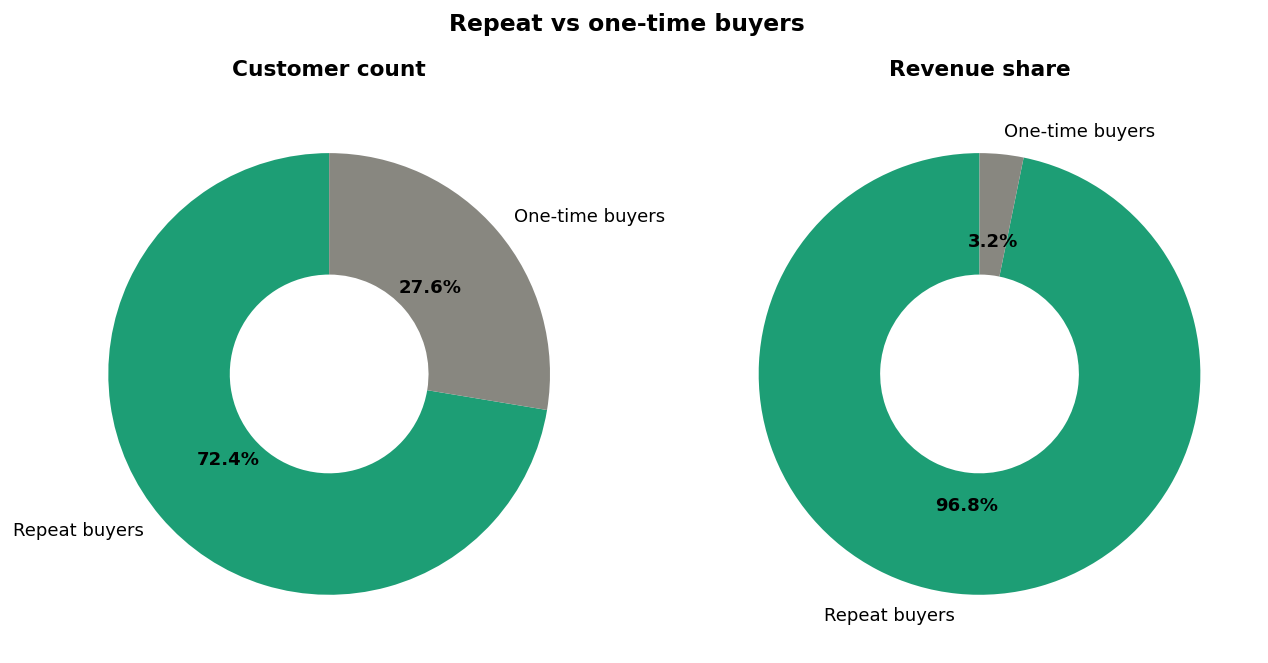

Repeat buyers   : 4,255  (72.4%)
One-time buyers : 1,623 (27.6%)
Repeat buyer revenue share : 96.8%


In [7]:
orders_per_cust = df.groupby('Customer ID')['Invoice'].nunique()
repeat          = (orders_per_cust > 1).sum()
one_time        = (orders_per_cust == 1).sum()
total_custs     = repeat + one_time

# Revenue split
repeat_ids      = orders_per_cust[orders_per_cust > 1].index
one_time_ids    = orders_per_cust[orders_per_cust == 1].index
repeat_rev      = df[df['Customer ID'].isin(repeat_ids)]['TotalRevenue'].sum()
one_time_rev    = df[df['Customer ID'].isin(one_time_ids)]['TotalRevenue'].sum()

fig, axes = plt.subplots(1, 2, figsize=(10, 5))

for ax, values, title in [
    (axes[0], [repeat, one_time], 'Customer count'),
    (axes[1], [repeat_rev, one_time_rev], 'Revenue share')
]:
    wedges, texts, autotexts = ax.pie(
        values,
        labels=[f'Repeat buyers', 'One-time buyers'],
        colors=[GREEN, GRAY],
        autopct='%1.1f%%', startangle=90,
        wedgeprops={'width': 0.55},
        textprops={'fontsize': 10}
    )
    for at in autotexts:
        at.set_fontweight('bold')
    ax.set_title(title, fontsize=12, fontweight='bold', pad=12)

plt.suptitle('Repeat vs one-time buyers', fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig(OUTPUT_DIR + r'\02_repeat_vs_onetime.png', bbox_inches='tight')
plt.show()

print(f"Repeat buyers   : {repeat:,}  ({repeat/total_custs*100:.1f}%)")
print(f"One-time buyers : {one_time:,} ({one_time/total_custs*100:.1f}%)")
print(f"Repeat buyer revenue share : {repeat_rev/(repeat_rev+one_time_rev)*100:.1f}%")

---
## 8. EDA summary — key findings

In [9]:
print('='*50)
print('         EDA KEY FINDINGS')
print('='*50)
print(f'Total revenue (2yr)         : \u00a3{df["TotalRevenue"].sum():>12,.0f}')
print(f'UK revenue share            : {uk_pct:>11.1f}%')
print(f'Number of countries         : {df["Country"].nunique():>12,}')
print(f'Median order value          : \u00a3{df.groupby("Invoice")["TotalRevenue"].sum().median():>11,.2f}')
print(f'Repeat buyers               : {repeat/total_custs*100:>11.1f}%')
print(f'Top 10% customers drive     : {top10_rev:>11.1f}% of revenue')
print(f'Top 20% customers drive     : {top20_rev:>11.1f}% of revenue')
print('='*50)
print()
print('ANCHOR STAT for interviews:')
print(f'"Top 20% of customers drive {top20_rev:.1f}% of revenue —')
print( ' this Pareto concentration is exactly why RFM segmentation matters."')

         EDA KEY FINDINGS
Total revenue (2yr)         : £  17,743,429
UK revenue share            :        83.0%
Number of countries         :           41
Median order value          : £     305.25
Repeat buyers               :        72.4%
Top 10% customers drive     :        63.9% of revenue
Top 20% customers drive     :        77.2% of revenue

ANCHOR STAT for interviews:
"Top 20% of customers drive 77.2% of revenue —
 this Pareto concentration is exactly why RFM segmentation matters."


---
## Notebook summary

| Finding | Value |
|---|---|
| Total 2-yr revenue | £17,743,429 |
| UK revenue share | 83.0% |
| Countries served | 40 |
| Median order value | £305 |
| Repeat buyer rate | 72.4% |
| Top 10% customers → revenue | 63.9% |
| Top 20% customers → revenue | 77.2% |

**Next:** `03_rfm_scoring.ipynb` — RFM segmentation and churn risk scoring.